# Birth parameters, common envelopes, and the DCO mass plane
**Author: Maryam Ahsan**

> **NOTE:** The work in this noteboook was inspired while working through [`tutorial_2_analysis_of_a_population_of_gravitational_wave_sources.ipynb`](https://github.com/FloorBroekgaarden/GROWL-catalog-public/blob/main/onboarding_growl/tutorial_2_analysis_of_a_population_of_gravitational_wave_sources.ipynb) as part of GROWL onboarding, which is why some blocks of code and conventions/asssumptions used here will be similar to the ones in tutorial 2.That is the notebook to be studied to understand the physics and working done here.
>
>AI was used to help write the code in [Section 2](#2-Load-compact-binaries-and-join-their-initial-conditions) block 1.

This is companion investigation to GROWL Notebook 2, using the **same** van Son et al. COMPAS weighted HDF5 file.

In this notebook we, 
1. Join the birth parameters of **merging Binary Black Holes (BBHs)** to their outcomes through `SEED`; compare initial mass ratio and initial primary mass for 0, 1, and 2+ common-envelope (CE) events.
2. Extend the mass-plane investigation: all BBHs split by Hubble-time merger status; all merging BBHs/BH–NSs/NS–NSs; then all three types split by merger status.

In [2]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

DATA_PATH = Path(r"E:/GitHub/Data/COMPAS_Output_wWeights.h5") 
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .18})


## 1. Inspect the file and identify birth-parameter columns

In [3]:
with h5py.File(DATA_PATH, "r") as f:
    for group_name in ("BSE_System_Parameters", "BSE_Double_Compact_Objects", "BSE_RLOF"):
        group = f[group_name]
        print(f"\n{group_name}: {len(group['SEED']):,} rows")
        print("  " + ", ".join(group.keys()))



BSE_System_Parameters: 10,000,000 rows
  Mass@ZAMS(1), Mass@ZAMS(2), Metallicity@ZAMS(1), SEED, Stellar_Type@ZAMS(1), Stellar_Type@ZAMS(2)

BSE_Double_Compact_Objects: 2,523,122 rows
  CE_Event_Counter, Coalescence_Time, Immediate_RLOF>CE, MT_Donor_Hist(1), MT_Donor_Hist(2), Mass(1), Mass(2), Merges_Hubble_Time, Metallicity@ZAMS(1), Optimistic_CE, SEED, Stellar_Type(1), Stellar_Type(2), Time, mixture_weight

BSE_RLOF: 31,878,423 rows
  CEE>MT, Eccentricity<MT, Eccentricity>MT, MT_Event_Counter, Mass(1)<MT, Mass(1)>MT, Mass(2)<MT, Mass(2)>MT, RLOF(1)>MT, RLOF(2)>MT, SEED


In [4]:
birth_cols = {
        "M1_zams": "Mass@ZAMS(1)",
        "M2_zams": "Mass@ZAMS(2)",
        "Z_zams": "Metallicity@ZAMS(1)",
    }

print("Birth columns selected:", birth_cols)

Birth columns selected: {'M1_zams': 'Mass@ZAMS(1)', 'M2_zams': 'Mass@ZAMS(2)', 'Z_zams': 'Metallicity@ZAMS(1)'}


## 2. Load compact binaries and join their initial conditions

The `(1)` and `(2)` DCO masses follow **stellar lineage**, whereas the plot uses sorted final compact-object masses `m1 >= m2`. For initial `q`, the **ZAMS masses** are used. Birth parameters only read for matching seeds in chunks so the ten-million-row birth table does not become an enormous DataFrame. An inner join drops DCOs without a matching birth row and reports the count.

In [5]:
DCO_COLS = ["SEED", "Mass(1)", "Mass(2)", "Stellar_Type(1)", "Stellar_Type(2)",
            "Merges_Hubble_Time", "CE_Event_Counter", "mixture_weight"]

with h5py.File(DATA_PATH, "r") as f:
    g = f["BSE_Double_Compact_Objects"]

    # c: g[c][()] is a dictionary comprehension that creates a dictionary where the keys are the
    # column names in DCO_COLS and the values are the corresponding datasets read from the HDF5 file.
    # The [()] syntax is used to read the entire dataset into memory as a numpy array.
    dco = pd.DataFrame({c: g[c][()] for c in DCO_COLS})

# renaming columns for clarity and consistency
dco = dco.rename(columns={"Mass(1)":"remnant1", "Mass(2)":"remnant2",
                          "Stellar_Type(1)":"type1", "Stellar_Type(2)":"type2",
                          "Merges_Hubble_Time":"merges", "CE_Event_Counter":"n_CE",
                          "mixture_weight":"w"})

# why assert? Because we want to ensure that the data meets certain conditions before proceeding with further analysis. 
# The first assertion checks that the SEED values are unique, which is important for a one-to-one birth join.
# The second assertion checks that the mixture weights are not null and greater than zero, which is necessary for making coloured plots
assert dco.SEED.is_unique, "DCO seeds must be unique for a one-to-one birth join"
assert dco.w.notna().all() and (dco.w > 0).all(), "Check mixture_weight before making log colour plots"

# ordering the remnant masses so that m1 >= m2, to stay consistent with tutorial_2
dco["m1"] = np.maximum(dco.remnant1, dco.remnant2)
dco["m2"] = np.minimum(dco.remnant1, dco.remnant2)

# creating a new column "kind" to store type label
dco["kind"] = np.select([(dco.type1.eq(14) & dco.type2.eq(14)), (dco.type1.eq(14) ^ dco.type2.eq(14)), (dco.type1.eq(13) & dco.type2.eq(13))],
                        ["BBH", "BH–NS", "NS–NS"],
                        default="other")

print(dco.groupby(["kind", "merges"], dropna=False).agg(rows=("SEED","size"), weight=("w","sum")))


                 rows         weight
kind  merges                        
BBH   0        632826  102778.217079
      1       1640550   14911.176778
BH–NS 0         51737    9396.196333
      1        192673    2918.325499
NS–NS 0          3414   12708.927155
      1          1922    6507.631762


In [11]:
# Here we target DCO with kind == BBH such that merge (within a Bubble time) == 1 and get their SEED
target = dco.loc[dco.kind.eq("BBH") & dco.merges.eq(1)].copy()
target_seeds = pd.Index(target.SEED)

# To hold the matching birth-parameter rows from each chunk.
parts = []

with h5py.File(DATA_PATH, "r") as f:

    g = f["BSE_System_Parameters"]
    n = len(g["SEED"]) # Total number of simulated binaries.

    # Read the large birth table in chunks of 250,000 rows.
    for start in range(0, n, 250_000):
        end = min(start + 250_000, n)
        seeds = g["SEED"][start:end]

        # True for rows whose SEED belongs to a merging BBH in `target`.
        keep = target_seeds.get_indexer(seeds) >= 0

        if keep.any():
            # Keep only the matching seeds and their birth parameters.
            chunk = {"SEED": seeds[keep]}
            for alias, col in birth_cols.items():
                chunk[alias] = g[col][start:end][keep]

            parts.append(pd.DataFrame(chunk))

# Combine the matching rows from all chunks into one birth-parameter table.         
birth = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=["SEED", *birth_cols])

# Each birth binary should appear once, so this guards against duplicate SEEDs.
assert birth.SEED.is_unique, "Birth seeds are not unique: inspect BSE_System_Parameters"

# Match each merging target's outcome to its original stellar masses using SEED.
# `validate="one_to_one"` checks for duplicate keys on both sides of the join.
joined = target.merge(birth, on="SEED", how="inner", validate="one_to_one")

print(f"Matched {len(joined):,} of {len(target):,} merging BBHs; missing {len(target)-len(joined):,}")

# An inner join would otherwise quietly discard unmatched BBHs.
assert len(joined) == len(target), "Missing birth records: inspect SEED values and file provenance"

# Birth mass ratio: smaller initial stellar mass / larger initial stellar mass.
joined["q_zams"] = np.minimum(joined.M1_zams, joined.M2_zams) / np.maximum(joined.M1_zams, joined.M2_zams)

# Catch zero/invalid birth masses or an impossible mass ratio before plotting.
assert ((joined.q_zams > 0) & (joined.q_zams <= 1) & (joined.M1_zams > 0)).all()

# Use a logarithmic initial-primary-mass coordinate for the plots.
joined["log_M1_zams"] = np.log10(joined.M1_zams.astype(float))

# Calculate its logarithm here, alongside the other birth parameters.
assert (joined.Z_zams > 0).all(), "Cannot take log10 of zero or negative metallicity"
joined["log_Z_zams"] = np.log10(joined.Z_zams.astype(float))

# Assign the requested outcome label from the number of CE events.
joined["channel"] = np.select([joined.n_CE.eq(0), joined.n_CE.eq(1), joined.n_CE.ge(2)],
                               ["0 CE (stable MT label)", "1 CE", "2+ CE"], default="unknown")

print(joined.groupby("channel").agg(rows=("SEED","size"), weight=("w","sum")))


Matched 1,640,550 of 1,640,550 merging BBHs; missing 0
                           rows        weight
channel                                      
0 CE (stable MT label)   452787   4106.441572
1 CE                    1180083  10520.020159
2+ CE                      7680    284.715047


### Initial mass ratio versus initial primary mass/Z_zams

In [ ]:
channels = ["0 CE (stable MT label)", "1 CE", "2+ CE"]
colors = ["#168b83", "#df853e", "#7651a8"]

#### Hexbin: q vs. M1

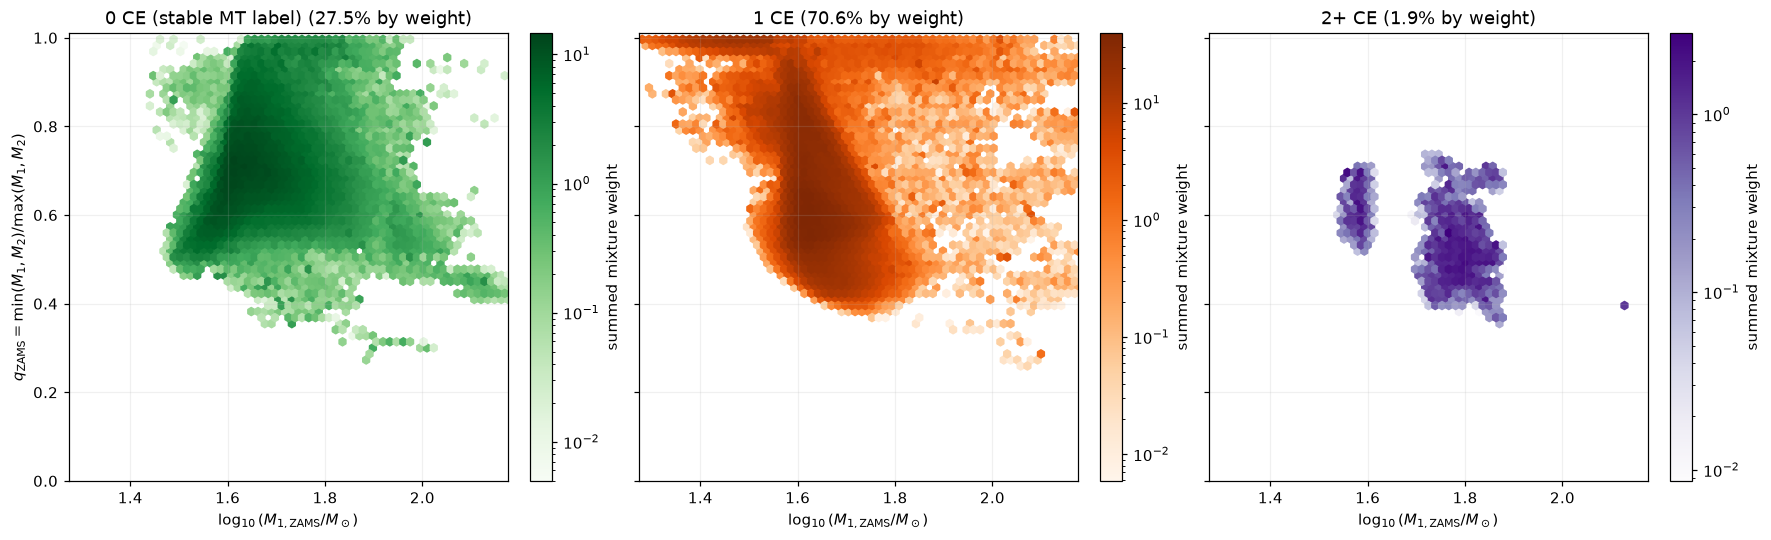

In [ ]:
xlim = np.quantile(joined.log_M1_zams, [0, 1])
ylim = (0, 1.01)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True, constrained_layout=True)

for ax, label, cmap in zip(axes, channels, ["Greens", "Oranges", "Purples"]):
    s = joined[joined.channel.eq(label)]
    if len(s):
        h = ax.hexbin(s.log_M1_zams, s.q_zams, C=s.w, reduce_C_function=np.sum,
                      gridsize=65, extent=(*xlim, *ylim), mincnt=1, norm=LogNorm(), cmap=cmap)
        fig.colorbar(h, ax=ax, label="summed mixture weight")
    ax.set(title=f"{label} ({s.w.sum()/joined.w.sum():.1%} by weight)",
           xlabel=r"$\log_{10}(M_{1,\rm ZAMS}/M_\odot)$",
           xlim=xlim,
           ylim=ylim)
axes[0].set_ylabel(r"$q_{\rm ZAMS} = \min(M_1,M_2)/\max(M_1,M_2)$")
plt.show()


#### Hexbin: q vs. Z

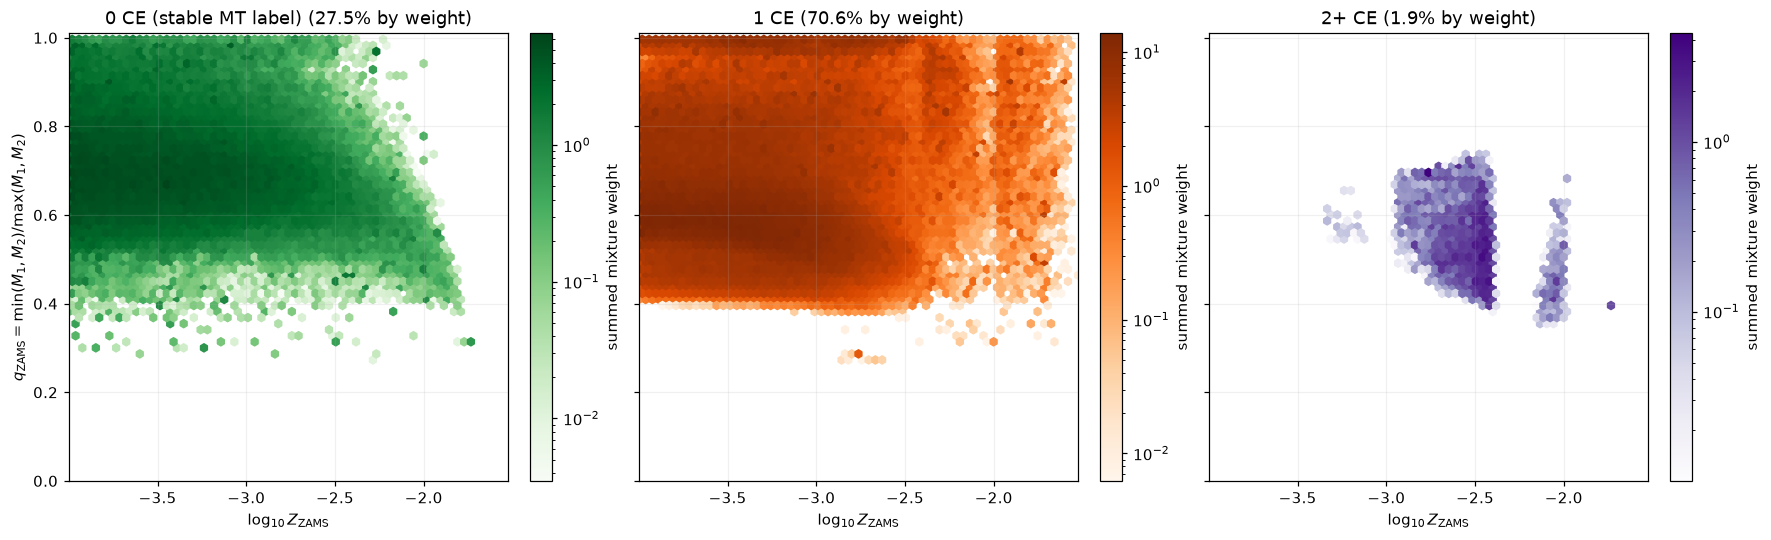

In [ ]:
xlim = (joined.log_Z_zams.min(), joined.log_Z_zams.max())
ylim = (0, 1.01)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True, constrained_layout=True)

for ax, label, cmap in zip(axes, channels, ["Greens", "Oranges", "Purples"]):
    s = joined[joined.channel.eq(label)]
    if len(s):
        h = ax.hexbin(s.log_Z_zams, s.q_zams, C=s.w, reduce_C_function=np.sum,
                      gridsize=65, extent=(*xlim, *ylim), mincnt=1, norm=LogNorm(), cmap=cmap)
        fig.colorbar(h, ax=ax, label="summed mixture weight")
    ax.set(title=f"{label} ({s.w.sum()/joined.w.sum():.1%} by weight)",
           xlabel=r"$\log_{10} Z_{\rm ZAMS}$",
           xlim=xlim,
           ylim=ylim)
axes[0].set_ylabel(r"$q_{\rm ZAMS} = \min(M_1,M_2)/\max(M_1,M_2)$")
plt.show()

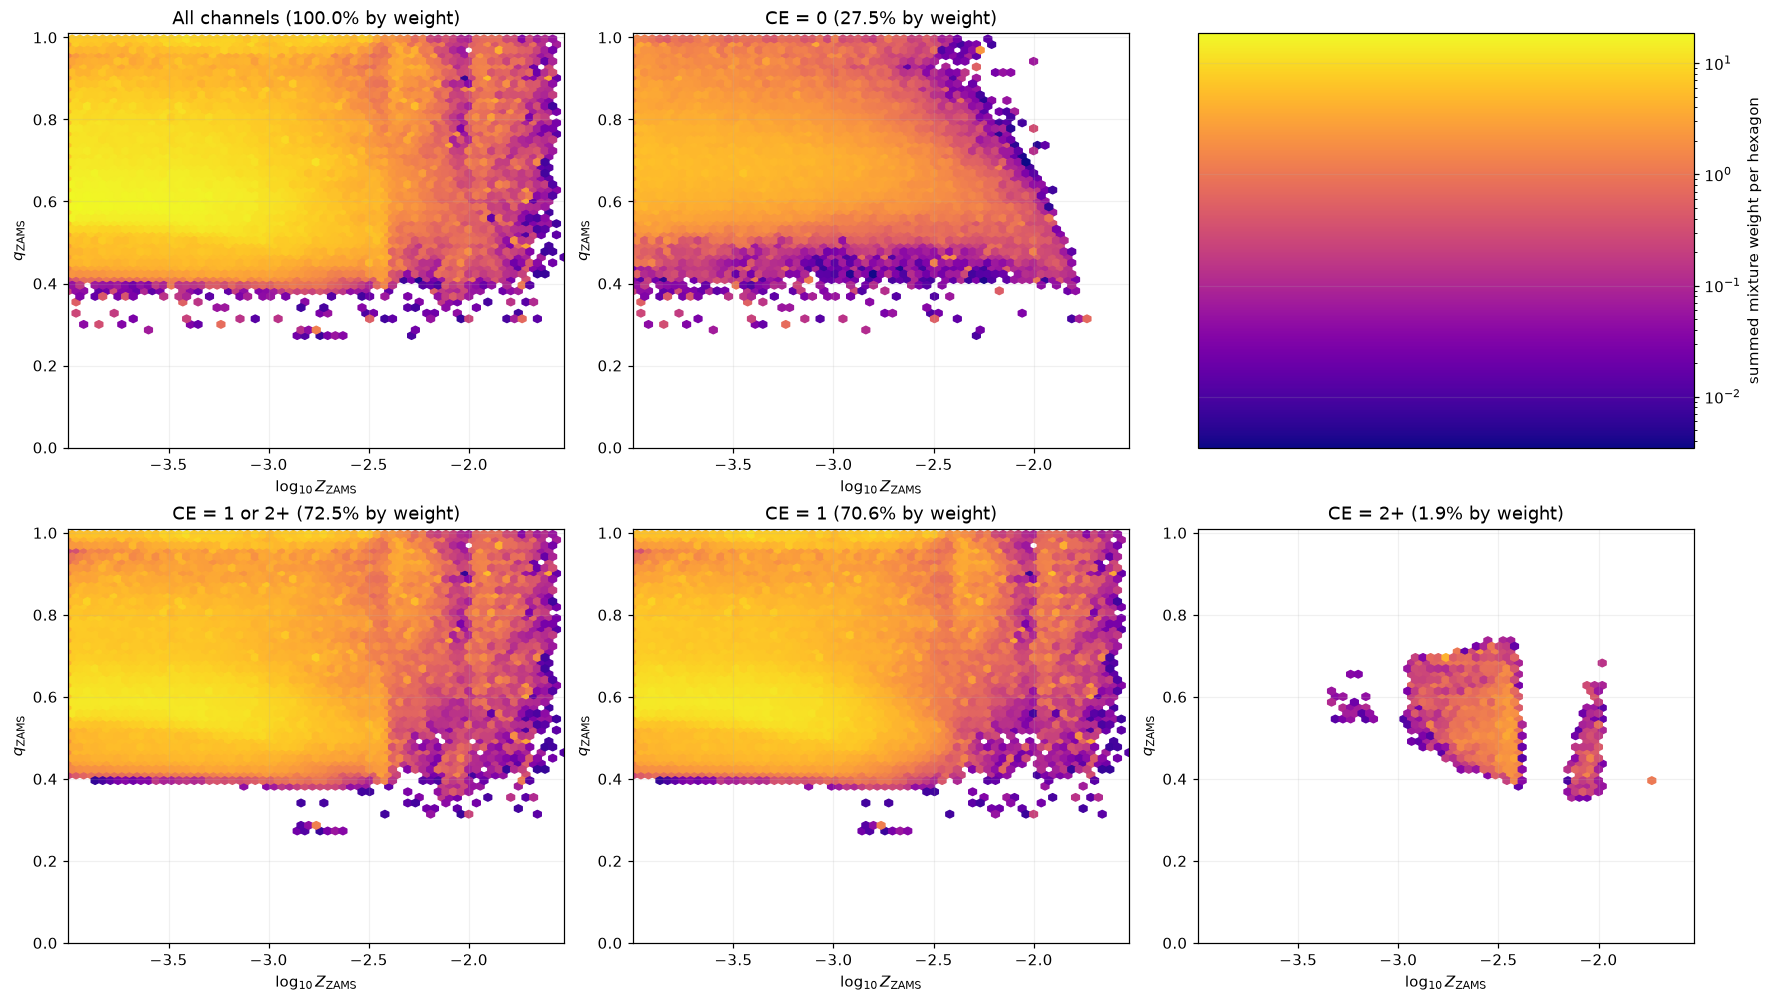

In [28]:
groups = [
    (joined, "All channels"),
    (joined[joined.n_CE.eq(0)], "CE = 0"),
    (joined[joined.n_CE.ge(1)], "CE = 1 or 2+"),
    (joined[joined.n_CE.eq(1)], "CE = 1"),
    (joined[joined.n_CE.ge(2)], "CE = 2+"),
]

xlim = (joined.log_Z_zams.min(), joined.log_Z_zams.max())
ylim = (0, 1.01)

fig = plt.figure(figsize=(16, 9), constrained_layout=True)
grid = fig.add_gridspec(2, 3)

# The top-right position is reserved for the shared colour bar.
plot_axes = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
    fig.add_subplot(grid[1, 0]),
    fig.add_subplot(grid[1, 1]),
    fig.add_subplot(grid[1, 2]),
]
colorbar_ax = fig.add_subplot(grid[0, 2])

hexbins = []

for ax, (s, label) in zip(plot_axes, groups):
    h = ax.hexbin( s.log_Z_zams, s.q_zams, C=s.w, reduce_C_function=np.sum,
        gridsize=65, extent=(*xlim, *ylim), mincnt=1, cmap="plasma")
    hexbins.append(h)

    fraction = s.w.sum() / joined.w.sum()
    ax.set_title(f"{label} ({fraction:.1%} by weight)")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$\log_{10} Z_{\rm ZAMS}$")
    ax.set_ylabel(r"$q_{\rm ZAMS}$")

# Find one colour range covering all five plots.
positive_values = np.concatenate([
    np.asarray(h.get_array())[np.asarray(h.get_array()) > 0]
    for h in hexbins
])

shared_norm = LogNorm( vmin=positive_values.min(), vmax=positive_values.max())

for h in hexbins:
    h.set_norm(shared_norm)

fig.colorbar( hexbins[0], cax=colorbar_ax, label="summed mixture weight per hexagon")

plt.show()

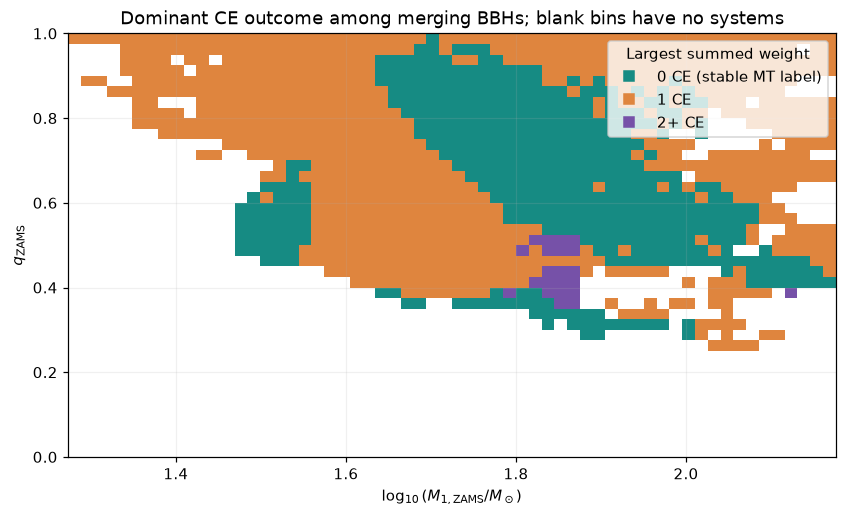

In [ ]:
edges_x = np.linspace(*xlim, 61)
edges_y = np.linspace(0, 1, 41)

counts = np.stack([np.histogram2d(joined.loc[joined.channel.eq(label), "log_M1_zams"],
                                  joined.loc[joined.channel.eq(label), "q_zams"],
                                  bins=(edges_x, edges_y),
                                  weights=joined.loc[joined.channel.eq(label), "w"])[0]
                   for label in channels])

totals = counts.sum(axis=0)
winner = np.argmax(counts, axis=0).astype(float)
winner[totals == 0] = np.nan

fig, ax = plt.subplots(figsize=(9, 5))
ax.pcolormesh(edges_x, edges_y, np.ma.masked_invalid(winner).T,
              cmap=ListedColormap(colors), norm=BoundaryNorm([-.5,.5,1.5,2.5], 3), shading="flat")
ax.legend(handles=[Line2D([], [], color=c, marker="s", ls="", label=label)
                   for c, label in zip(colors, channels)], title="Largest summed weight", loc="best")
ax.set(xlabel=r"$\log_{10}(M_{1,\rm ZAMS}/M_\odot)$", ylabel=r"$q_{\rm ZAMS}$",
       title="Dominant CE outcome among merging BBHs; blank bins have no systems")
plt.show()


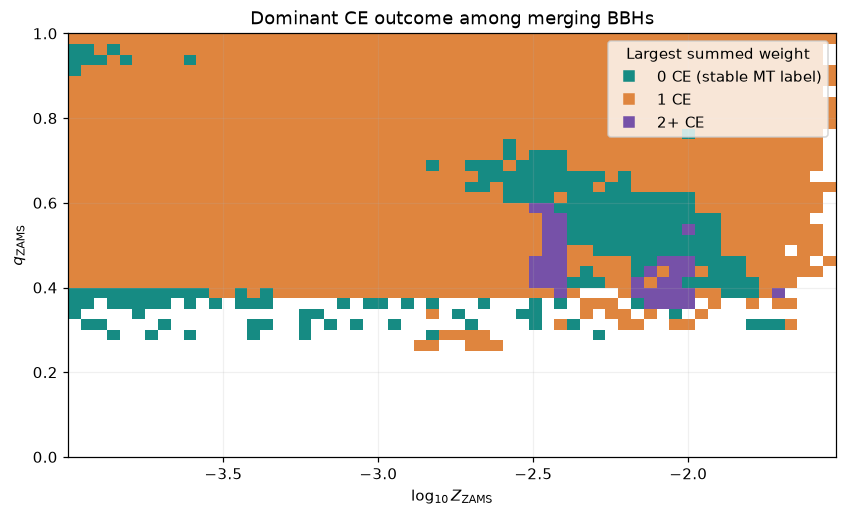

In [29]:
# Bin logarithmic birth metallicity on the x-axis.
edges_x = np.linspace(joined.log_Z_zams.min(), joined.log_Z_zams.max(), 61)
edges_y = np.linspace(0, 1, 41)

counts = np.stack([np.histogram2d( joined.loc[joined.channel.eq(label), "log_Z_zams"],
                                  joined.loc[joined.channel.eq(label), "q_zams"],
                                  bins=(edges_x, edges_y), weights=joined.loc[joined.channel.eq(label), "w"])[0]
                    for label in channels
])

# For each bin, find which channel has the largest summed weight.
totals = counts.sum(axis=0)
winner = np.argmax(counts, axis=0).astype(float)
winner[totals == 0] = np.nan  # Leave bins with no systems blank.

fig, ax = plt.subplots(figsize=(9, 5))

ax.pcolormesh(edges_x, edges_y, np.ma.masked_invalid(winner).T,
              cmap=ListedColormap(colors), norm=BoundaryNorm([-.5,.5,1.5,2.5], 3), shading="flat")
ax.legend(handles=[Line2D([], [], color=c, marker="s", ls="", label=label)
                   for c, label in zip(colors, channels)], title="Largest summed weight", loc="best")
ax.set(xlabel=r"$\log_{10} Z_{\rm ZAMS}$", ylabel=r"$q_{\rm ZAMS}$",
       title="Dominant CE outcome among merging BBHs")
plt.show()

## 3. Mass plane: all BBHs, by Hubble-time merger status


Full DCO mass range: 0–183.86 solar masses; original-style reference: 46.30


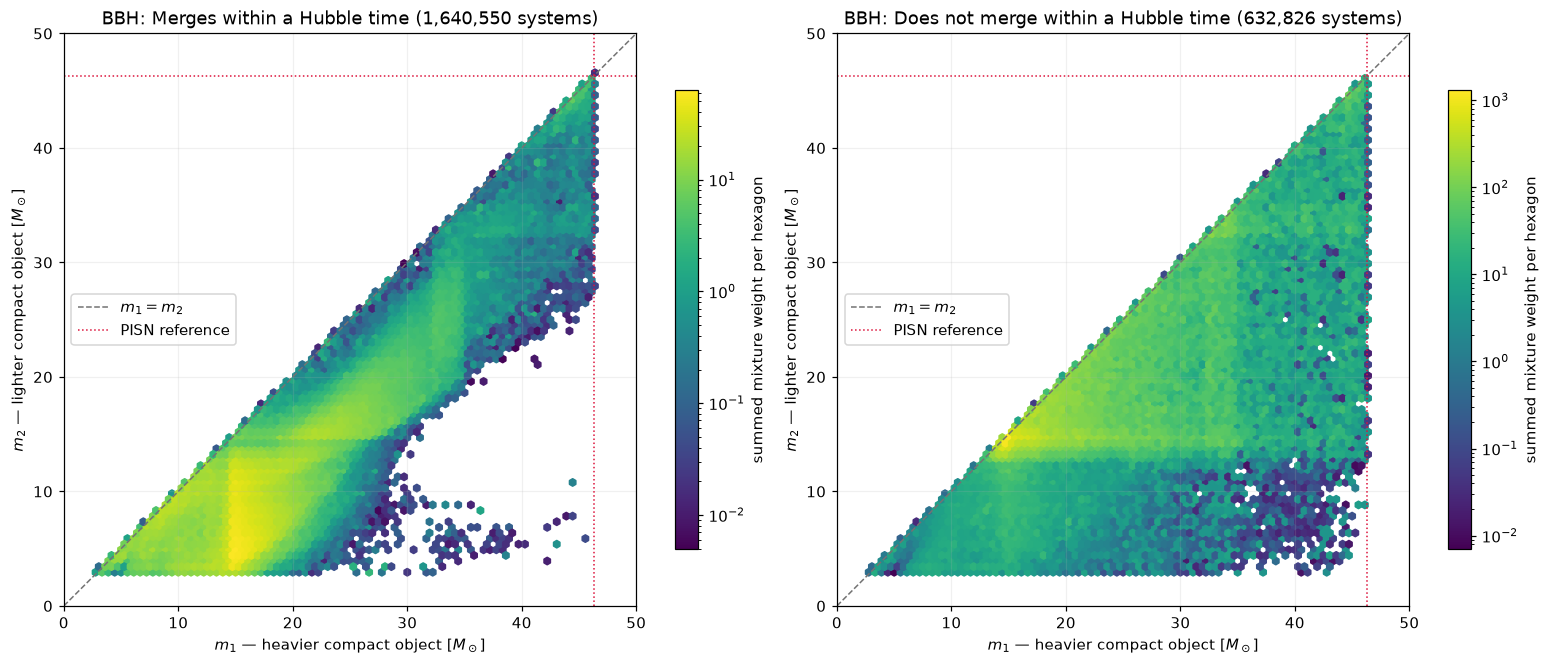

In [ ]:
bbh = dco[dco.kind.eq("BBH")]
merging_bbh = bbh[bbh.merges.eq(1)]
assert len(merging_bbh) and (merging_bbh.m1 < 100).any()
m_lim = merging_bbh.loc[merging_bbh.m1.lt(100), "m1"].max()
max_mass = float(np.nanmax(dco.loc[dco.kind.ne("other"), ["m1", "m2"]].to_numpy()))
#upper = max_mass * 1.025
print(f"Full DCO mass range: 0–{max_mass:.2f} solar masses; original-style reference: {m_lim:.2f}")

def mass_axes(ax):
    ax.plot([0, 50], [0, 50], color="0.45", lw=1, ls="--", label=r"$m_1=m_2$")
    ax.axvline(m_lim, color="crimson", lw=1, ls=":")
    ax.axhline(m_lim, color="crimson", lw=1, ls=":", label="PISN reference")
    ax.set(xlim=(0, 50), ylim=(0, 50), aspect="equal",
           xlabel=r"$m_1$ — heavier compact object [$M_\odot$]",
           ylabel=r"$m_2$ — lighter compact object [$M_\odot$]")
    ax.legend()

def bbh_background(ax, frame, cmap="viridis"):
    if frame.empty: return None
    return ax.hexbin(frame.m1, frame.m2, C=frame.w, reduce_C_function=np.sum,
                     gridsize=90, extent=(0, 50, 0, 50), mincnt=1,
                     norm=LogNorm(), cmap=cmap, zorder=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, status, title in zip(axes, (1, 0), ("Merges within a Hubble time", "Does not merge within a Hubble time")):
    group = bbh[bbh.merges.eq(status)]
    h = bbh_background(ax, group)
    mass_axes(ax)
    ax.set_title(f"BBH: {title} ({len(group):,} systems)")
    if h is not None: fig.colorbar(h, ax=ax, shrink=.75, label="summed mixture weight per hexagon")
plt.show()


## 4. All merging DCO types



          rows        weight
kind                        
BBH    1640550  14911.176778
BH–NS   192673   2918.325499
NS–NS     1922   6507.631762


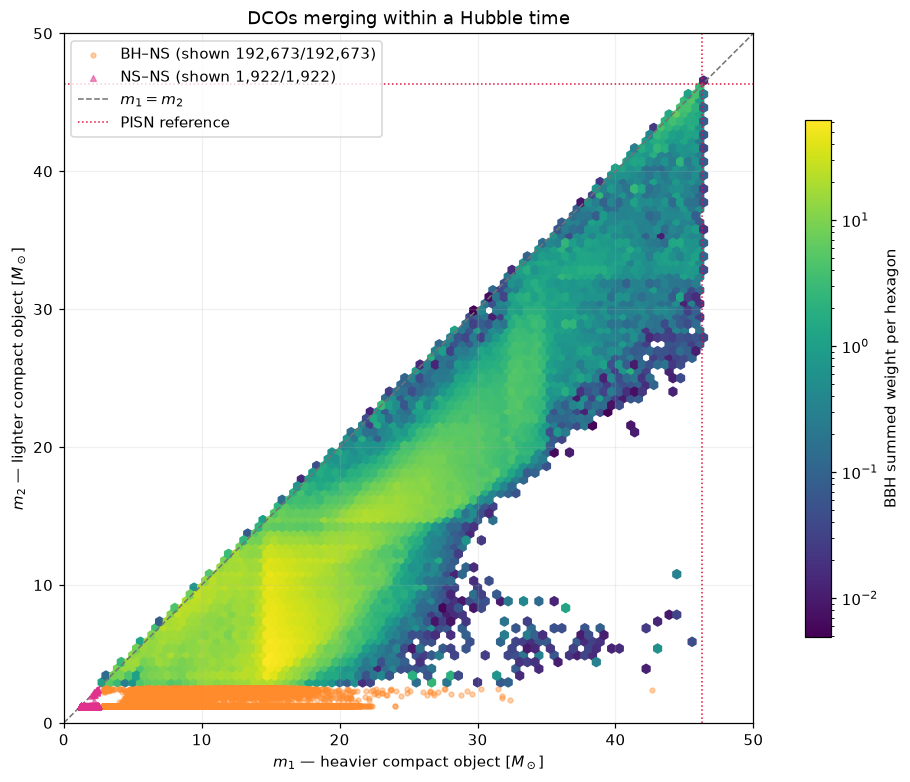

In [ ]:
POINT_CAP = 200000
OVERLAY_STYLES = {"BH–NS": dict(color="#ff8b2d", marker="o", s=10, alpha=.4),
                  "NS–NS": dict(color="#e0328c", marker="^", s=14, alpha=.5)}

def overlay_types(ax, frame, seed=21):
    for j, (kind, style) in enumerate(OVERLAY_STYLES.items()):
        sub = frame[frame.kind.eq(kind)]
        view = sub.sample(min(len(sub), POINT_CAP), random_state=seed+j) if len(sub) else sub
        ax.scatter(view.m1, view.m2, zorder=3+j, rasterized=True,
                   label=f"{kind} (shown {len(view):,}/{len(sub):,})", **style)

merging = dco[dco.merges.eq(1) & dco.kind.ne("other")]
print(merging.groupby("kind").agg(rows=("SEED","size"), weight=("w","sum")))
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
h = bbh_background(ax, merging[merging.kind.eq("BBH")])
overlay_types(ax, merging)
mass_axes(ax)
ax.set_title("DCOs merging within a Hubble time")
ax.legend(loc="upper left")
if h is not None: fig.colorbar(h, ax=ax, shrink=.75, label="BBH summed weight per hexagon")
plt.show()


## 5. All DCO types, split by merger status

                 rows         weight
merges kind                         
0      BBH     632826  102778.217079
       BH–NS    51737    9396.196333
       NS–NS     3414   12708.927155
1      BBH    1640550   14911.176778
       BH–NS   192673    2918.325499
       NS–NS     1922    6507.631762


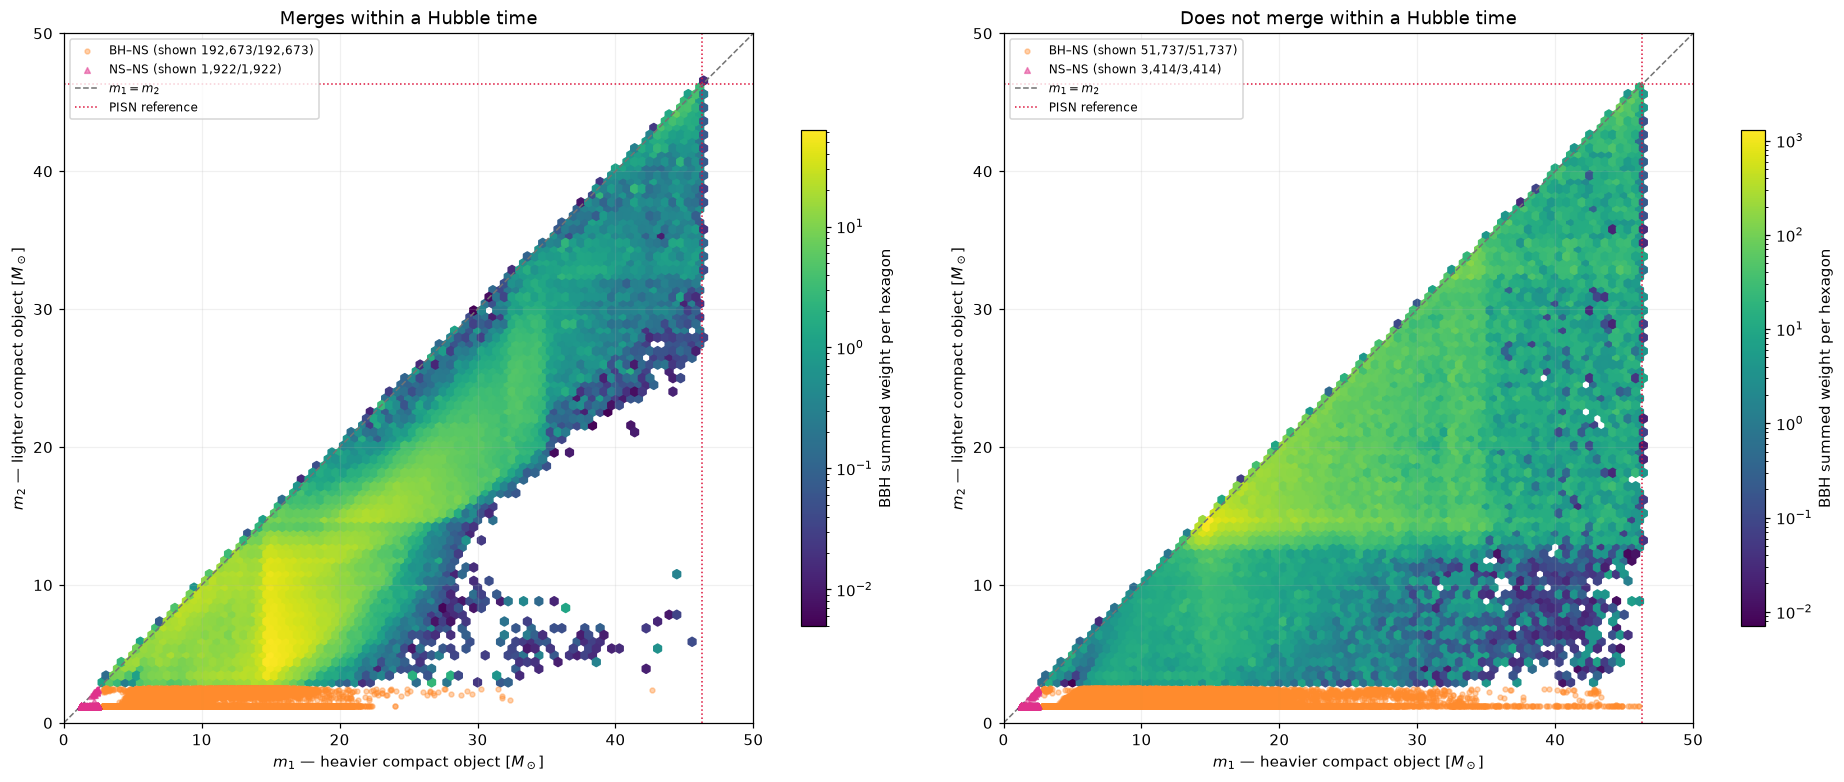

In [ ]:
all_dco = dco[dco.kind.ne("other")]
print(all_dco.groupby(["merges", "kind"]).agg(rows=("SEED","size"), weight=("w","sum")))
fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)
for ax, status, title in zip(axes, (1, 0), ("Merges within a Hubble time", "Does not merge within a Hubble time")):
    frame = all_dco[all_dco.merges.eq(status)]
    h = bbh_background(ax, frame[frame.kind.eq("BBH")])
    overlay_types(ax, frame, seed=42+status)
    mass_axes(ax)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    if h is not None: fig.colorbar(h, ax=ax, shrink=.72, label="BBH summed weight per hexagon")
plt.show()


## Questions to carry into the next pass

- Does the lower-right gap persist in **nonmerging BBHs**, or only after the Hubble-time cut?
- Does it remain when the other DCO types are included? Distinguish truly empty space from very low weighted occupancy and plotting resolution.
- In the initial-condition plots, do CE labels overlap strongly at fixed initial `(q, M1)`? Metallicity may explain additional structure. To test initial `(q, a)`, obtain a simulation output that actually includes ZAMS separation for the same SEEDs.
- For a true **birth-parameter predictor**, use all simulated binaries with well-defined outcomes, specify whether destroyed/non-DCO systems count, and split training/test data by binary SEED. The figures above describe the conditional merging-BBH sample, not a trained classifier.

Data: [van Son et al. Zenodo record](https://doi.org/10.5281/zenodo.7612755); see companion Notebook 2 for model details and attribution.
